In [62]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
# Import functions from src directory (src is ../src)
import sys
sys.path.append('../src')
from preprocess_TC_data import clean_track_data
from utils import nm2km, kt2kmh, haversine_vectorized
from wind_fields import max_wind_speeds_at_locations
from generate_exposure import generate_synthetic_portfolio
from vulnerbility import get_damage_ratio


In [102]:
housing_portfolio = generate_synthetic_portfolio(num_locs=1000)
print(housing_portfolio.head())

   location_id   latitude  longitude        tiv construction
0            1  29.986902 -85.777840  191187.27        Frame
1            2  30.735929 -85.349719  196135.26        Frame
2            3  30.451592 -84.952465  264808.06      Masonry
3            4  30.278256 -85.121330  356355.02        Frame
4            5  29.702824 -85.032127  468266.25        Frame


In [106]:
def calculate_tc_impacts(tc_track_file, housing_portfolio,full_report=False):
    # Clean and load the tropical cyclone track data
    tc_data = clean_track_data(tc_track_file, is_best_track=True)

    # Get lon lat touples for portfolio
    points = list(zip(housing_portfolio['latitude'], housing_portfolio['longitude']))
    max_wind_speeds = max_wind_speeds_at_locations(tc_data, points)
    
    # Compute damage ratios based on the maximum wind speeds
    damage_ratios = get_damage_ratio(max_wind_speeds)

    portfolio_damages = damage_ratios * housing_portfolio['tiv']
    total_damage = np.sum(portfolio_damages)
    print(f"Estimated total damage to portfolio: ${total_damage:,.2f}")


    if full_report:
        # Mean damage ratio
        mean_damage_ratio = np.mean(damage_ratios)
        print(f"Mean Damage Ratio: {mean_damage_ratio:.4f}")
        # Max damage ratio
        max_damage_ratio = np.max(damage_ratios)
        print(f"Max Damage Ratio: {max_damage_ratio:.4f}")
        # Locations with damage ratio > 0.5
        high_damage_locs = housing_portfolio[damage_ratios > 0.5]
        print(f"Number of locations with damage ratio > 0.5: {len(high_damage_locs)}")
        
        if len(high_damage_locs) > 0:
        #Mean damage ratio for high damage locations
            mean_high_damage_ratio = np.mean(damage_ratios[damage_ratios > 0.5])
            print(f"Mean Damage Ratio for locations with damage ratio > 0.5: {mean_high_damage_ratio:.4f}")

        


    return total_damage, portfolio_damages

_,_ = calculate_tc_impacts("../data/raw/bal142018.dat", housing_portfolio, full_report=True)

Estimated total damage to portfolio: $49,379,545.26
Mean Damage Ratio: 0.1480
Max Damage Ratio: 0.9879
Number of locations with damage ratio > 0.5: 144
Mean Damage Ratio for locations with damage ratio > 0.5: 0.8385


In [ ]:
input_file = "../data/raw/bal142018.dat"
output_file = "../data/processed/michael_2018_best_track.csv"

df = clean_track_data(input_file, is_best_track=True)
print(df.head())
df = df.iloc[:-35]

            timestamp  latitude  longitude  max_wind_speed_kt  \
0 2018-10-06 18:00:00      17.8      -86.6                 25   
1 2018-10-07 00:00:00      18.1      -86.9                 25   
2 2018-10-07 06:00:00      18.4      -86.8                 30   
3 2018-10-07 12:00:00      18.8      -86.4                 35   
4 2018-10-07 18:00:00      19.1      -85.7                 45   

   radius_max_wind_nm  min_pressure_mb storm_type  
0                  90             1006         LO  
1                  90             1004         LO  
2                 120             1004         TD  
3                 120             1003         TS  
4                  60              999         TS  


In [64]:
# Quick test 
lat1 = 25.0
lon1 = -80.0
lat2_array = np.array([30.0,31.0, 29.9])
lon2_array = np.array([-86.0, -85.0, -85.5])
distances = haversine_vectorized(lat1, lon1, lat2_array, lon2_array)

In [ ]:
kt2kmh(max_wind_speeds_at_locations(df, [(30.0, -86.0), (31.0, -85.0), (29.9, -85.5)]))

array([ 50.42813808,  21.37089338, 160.06576602])

Text(0.5, 1.0, 'Storm Trajectory with Wind Speed')

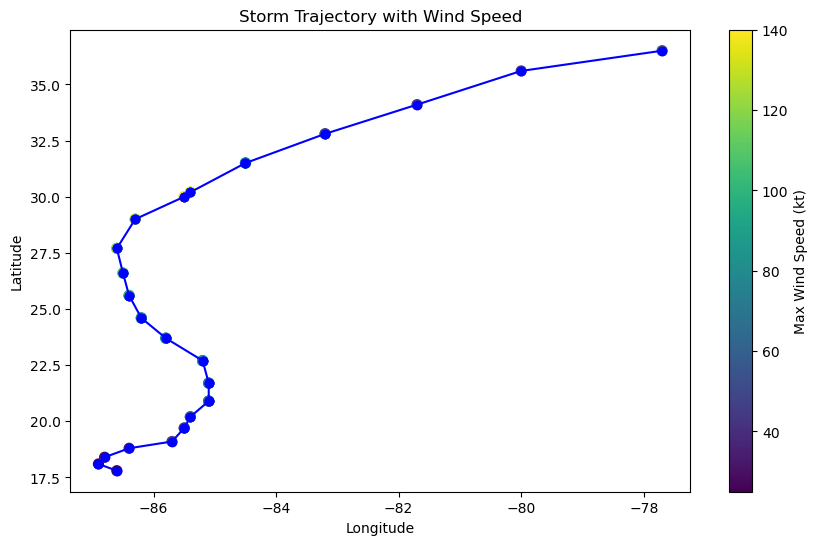

In [29]:
# Okay lets do a plot of the trajectory with the wind speed in color at each point 

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df['longitude'], df['latitude'], marker='o', linestyle='-', color='blue', label='Storm Path')
plt.scatter(df['longitude'], df['latitude'], c=df['max_wind_speed_kt'], cmap='viridis', s=50, label='Wind Speed')
plt.colorbar(label='Max Wind Speed (kt)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Storm Trajectory with Wind Speed')

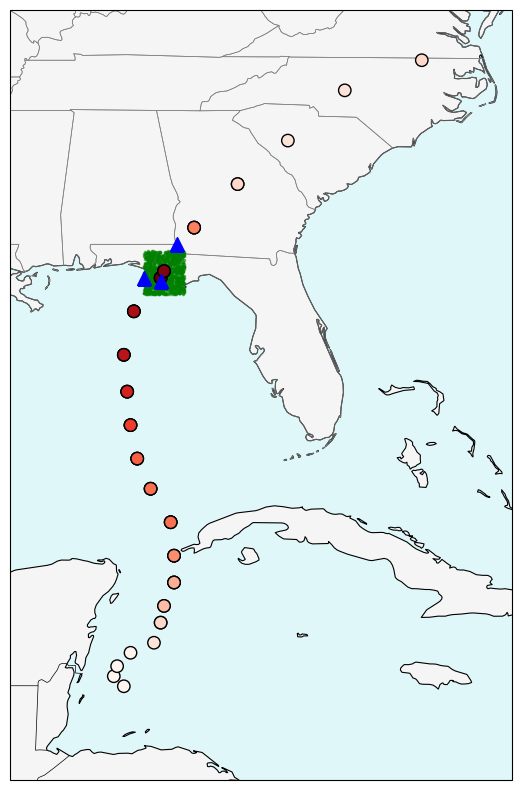

In [85]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
    
# 3. Add Map Features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.set_extent([-90, -75, 15, 38], crs=ccrs.PlateCarree())

track_sc = ax.scatter(
        df['longitude'],
        df['latitude'],
        c=df['max_wind_speed_kt'],
        cmap='Reds',
        s=80,
        edgecolor='black',
        vmin=34, vmax=140, # Scale from TS to Cat 5
        label='Storm Track',
        transform=ccrs.PlateCarree(),
        zorder=10 # Draw on top
    )

# Plot test points (houses)
ax.scatter(
    lon2_array,
    lat2_array,
    color='blue',
    marker='^',
    s=100,
    label='Test Points',
    transform=ccrs.PlateCarree(),
    zorder=15 # Draw on top
)

# Scatter all the housing portfolio points
ax.scatter(
    housing_portfolio['longitude'],
    housing_portfolio['latitude'],
    color='green',
    marker='.',
    s=10,
    alpha=0.5,
    label='Housing Portfolio',
    transform=ccrs.PlateCarree(),
    zorder=5 # Below test points and storm track
)


In [55]:
np.log(0.075/0.225)*5730/np.log(2)

np.float64(-9081.835129132227)

In [57]:
np.log(10)

np.float64(2.302585092994046)

In [58]:
25/4/4/4/4

0.09765625